## EDA and Preprocessing


In [37]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
TARGET_LABELS = {0: "No disease (0)", 1: "Disease (1)"}
TARGET_COLORS = {"No disease (0)": "#2b5c8f", "Disease (1)": "#c45345"}

FEATURE_LABELS = {'age': 'Age (years)', 'trestbps': 'Resting blood pressure (mm Hg)',
                  'chol': 'Serum cholesterol (mg/dL)', 'thalach': 'Maximum heart rate (beats/min)',
                  'oldpeak': 'ST depression (oldpeak, source units)'}


## 1. Understand the dataset

In [38]:
# Support running from either the project root or notebook/.
DATA_PATH = next(
    (p for p in [Path("data/raw/cleveland-data.csv"),
                 Path("../data/raw/cleveland-data.csv")] if p.is_file()),
    None,
)
if DATA_PATH is None:
    raise FileNotFoundError("Run this notebook from the project root or notebook/.")


In [39]:
COLUMNS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
TARGET = 'target'

# Keep the original diagnosis codes for auditing before binary recoding.
source = pd.read_csv(DATA_PATH, header=None, names=COLUMNS, na_values='?')
source = source.apply(pd.to_numeric, errors='raise')
if source[TARGET].isna().any() or not source[TARGET].isin([0, 1, 2, 3, 4]).all():
    raise ValueError("Expected complete source diagnosis codes in {0, 1, 2, 3, 4}.")
diagnosis_original = source[TARGET].copy()
raw = source.copy()
raw[TARGET] = (diagnosis_original > 0).astype(int)
# A plotting-only frame gives categorical hues explicit, stable labels.
print('Shape:', raw.shape)


Shape: (303, 14)


In [40]:
raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [41]:
raw.columns.to_list()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [42]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [43]:
raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Feature dictionary

The table below describes the source columns and their encodings. `target` is recoded to 0 (no disease) or 1 (disease present).

| Variable Name | Role | Type | Description | Values / Encoding | Units | Missing Values |
|---|---|---|---|---|---|---|
| `age` | Feature | Integer | Age of the patient | Continuous | years | no |
| `sex` | Feature | Categorical | Sex of the patient | `1` = male, `0` = female | - | no |
| `cp` | Feature | Categorical | Chest pain type | `1` = typical angina, `2` = atypical angina, `3` = non-anginal pain, `4` = asymptomatic | - | no |
| `trestbps` | Feature | Integer | Resting systolic blood pressure on admission to the hospital | Continuous | mm Hg | no |
| `chol` | Feature | Integer | Serum cholesterol | Continuous | mg/dL | no |
| `fbs` | Feature | Categorical | Fasting blood sugar > 120 mg/dL | `1` = true, `0` = false | - | no |
| `restecg` | Feature | Categorical | Resting electrocardiographic results | `0` = normal, `1` = ST-T abnormality, `2` = left ventricular hypertrophy | - | no |
| `thalach` | Feature | Integer | Maximum heart rate achieved | Continuous | beats/min | no |
| `exang` | Feature | Categorical | Exercise-induced angina | `1` = yes, `0` = no | - | no |
| `oldpeak` | Feature | Numeric | ST depression induced by exercise relative to rest | Continuous | - | no |
| `slope` | Feature | Categorical | Slope of the peak exercise ST segment | `1` = upsloping, `2` = flat, `3` = downsloping | - | no |
| `ca` | Feature | Categorical / Integer | Number of major vessels colored by fluoroscopy | `0–3` | - | yes |
| `thal` | Feature | Categorical | Thallium stress test result | `3` = normal, `6` = fixed defect, `7` = reversible defect | - | yes |
| `target` | Target | Categorical | Heart disease diagnosis | `0` = no disease, `1` = heart disease | - | no |

## 2. Basic data quality check

In [44]:
missing_summary = pd.DataFrame({
    'missing_count': raw.isna().sum(),
    'missing_percent': (raw.isna().mean() * 100).round(2),
})
missing_summary.sort_values('missing_count', ascending=False)


,missing_count,missing_percent
ca,4,1.32
thal,2,0.66
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00


In [45]:
raw[raw.isna().any(axis=1)]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


In [46]:
target_summary= pd.DataFrame({
    'count': raw['target'].value_counts(),
    'proportion': raw['target'].value_counts(normalize=True)
})

target_summary.sort_values(by = 'proportion',ascending=False)

,count,proportion
target,,
0,164,0.541254
1,139,0.458746


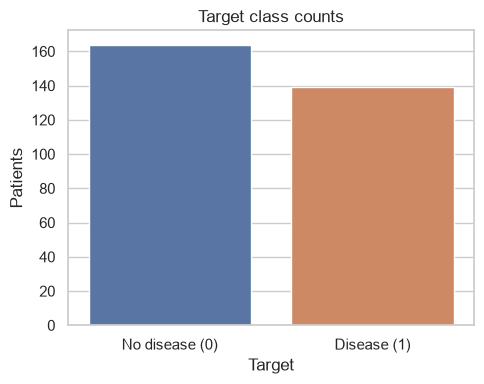

In [47]:
plt.figure(figsize=(5, 4))
sns.countplot(data=raw, x='target', hue='target', legend=False)
plt.xticks([0, 1], ['No disease (0)', 'Disease (1)'])
plt.title('Target class counts')
plt.xlabel('Target')
plt.ylabel('Patients')
plt.tight_layout()
plt.show()


In [48]:
print('Duplicate rows:', raw.duplicated().sum())
print('Duplicate predictor profiles:', raw.drop(columns=TARGET).duplicated().sum())
print('Rows with at least one missing feature:', raw.isna().any(axis=1).sum())
display(diagnosis_original.value_counts().sort_index().rename_axis('source_diagnosis')
        .to_frame('patients'))


Duplicate rows: 0
Duplicate predictor profiles: 0
Rows with at least one missing feature: 6


,patients
source_diagnosis,
0,164
1,55
2,36
3,35
4,13


### Observation after checking quality of the dataset

- The dataset comprises 303 observations, 13 input features, and 1 binary target: 164 instances in class 0 (54.1%) and 139 instances in class 1 (45.9%). There are no duplicate rows or duplicate feature sets.
- There are 4 missing values in ca and 2 in thal, distributed across 6 distinct rows. Retain missing values during EDA; learn the imputation strategy strictly from the training set.
- The original target contains integer codes from 0 to 4. Mapping all values greater than 0 to 1 serves the binary classification task and discards granular information regarding the original diagnostic severity levels.
- Values falling outside the IQR boundaries serve as flags for inspection rather than sufficient justification for dropping observations.

## 3. Split the dataset and EDA

In [49]:
TARGET='target'
raw_feature_cols = [c for c in raw.columns if c != TARGET]

X_all = raw[raw_feature_cols]
y_all = raw[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

In [50]:
def detect_outliers_and_uncommon(
    df, numeric_cols=None, categorical_cols=None, iqr_factor=1.5, rare_thresh=0.02
):
    """Detects statistical outliers in numerical columns (using IQR)

    and rare/uncommon categories in categorical columns.
    """
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = [c for c in df.columns if c not in numeric_cols]

    report = []
    outlier_indices = {}

    # --- 1. Numerical Outliers (IQR Method) ---
    for col in numeric_cols:
        series = df[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (iqr_factor * iqr)
        upper_bound = q3 + (iqr_factor * iqr)

        mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers = df[col][mask]

        outlier_indices[col] = df.index[mask].tolist()

        report.append(
            {
                "Column": col,
                "Type": "Numerical",
                "Outlier/Rare Count": len(outliers),
                "Outlier %": round((len(outliers) / len(df)) * 100, 2),
                "Criteria / Bounds": f"[{lower_bound:.2f}, {upper_bound:.2f}]",
                "Uncommon / Outlier Sample Values": (
                    sorted(outliers.unique().tolist()) if len(outliers) > 0 else []
                ),
            }
        )

    # --- 2. Categorical / Discrete Rare Values ---
    for col in categorical_cols:
        freq = df[col].value_counts(normalize=True, dropna=True)
        counts = df[col].value_counts(dropna=True)

        # Values that appear below threshold (e.g., < 2% of the dataset)
        rare_vals = freq[freq < rare_thresh].index.tolist()
        mask = df[col].isin(rare_vals)
        outlier_indices[col] = df.index[mask].tolist()

        rare_summary = [
            f"{val} (n={counts[val]}, {freq[val]*100:.1f}%)"
            for val in rare_vals
            if pd.notna(val)
        ]

        report.append(
            {
                "Column": col,
                "Type": "Categorical",
                "Outlier/Rare Count": mask.sum(),
                "Outlier %": round((mask.sum() / len(df)) * 100, 2),
                "Criteria / Bounds": f"Freq < {rare_thresh*100:.1f}% of observed values",
                "Uncommon / Outlier Sample Values": rare_summary,
            }
        )

    summary_df = pd.DataFrame(report)
    return summary_df, outlier_indices


In [51]:
# Inspect IQR outliers in continuous columns and low-frequency levels in categorical columns.
# This is a diagnostic only; flagged rows are not automatically removed.
summary_df, outlier_idx = detect_outliers_and_uncommon(
    X_train,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    iqr_factor=1.5,
    rare_thresh=0.03,
)
summary_df.sort_values(by='Outlier/Rare Count', ascending=False)


,Column,Type,Outlier/Rare Count,Outlier %,Criteria / Bounds,Uncommon / Outlier Sample Values
1,trestbps,Numerical,6,2.48,"[90.00, 170.00]","[172, 178, 180, 192, 200]"
2,chol,Numerical,5,2.07,"[113.38, 376.38]","[394, 407, 409, 417, 564]"
4,oldpeak,Numerical,4,1.65,"[-2.40, 4.00]","[4.2, 5.6, 6.2]"
3,thalach,Numerical,1,0.41,"[87.25, 213.25]",[71]
8,restecg,Categorical,1,0.41,Freq < 3.0% of observed values,"[1 (n=1, 0.4%)]"
0,age,Numerical,0,0.00,"[28.50, 80.50]",[]
5,sex,Categorical,0,0.00,Freq < 3.0% of observed values,[]
6,cp,Categorical,0,0.00,Freq < 3.0% of observed values,[]
7,fbs,Categorical,0,0.00,Freq < 3.0% of observed values,[]
9,exang,Categorical,0,0.00,Freq < 3.0% of observed values,[]


In [52]:
# Quantify skewness and inspect the actual IQR-flagged rows.
numeric_summary = X_train[numeric_cols].describe().T
numeric_summary['median'] = X_train[numeric_cols].median()
numeric_summary['skewness'] = X_train[numeric_cols].skew()
display(numeric_summary.round(2))
flagged_numeric_rows = sorted(set(index for col in numeric_cols for index in outlier_idx[col]))
print('Patients flagged by at least one numeric IQR rule:', len(flagged_numeric_rows))
display(X_train.loc[flagged_numeric_rows, numeric_cols])


,count,mean,std,min,25%,50%,75%,max,median,skewness
age,242.0,54.55,9.00,29.0,48.0,56.0,61.00,77.0,56.0,-0.17
trestbps,242.0,130.96,17.62,94.0,120.0,130.0,140.00,200.0,130.0,0.73
chol,242.0,249.84,52.85,126.0,212.0,244.5,277.75,564.0,244.5,1.22
thalach,242.0,149.96,22.69,71.0,134.5,153.5,166.00,202.0,153.5,-0.58
oldpeak,242.0,1.00,1.12,0.0,0.0,0.8,1.60,6.2,0.8,1.47


Patients flagged by at least one numeric IQR rule: 15


,age,trestbps,chol,thalach,oldpeak
14,52,172,199,162,0.5
48,65,140,417,157,0.8
83,68,180,274,150,1.6
91,62,160,164,145,6.2
121,63,150,407,154,4.0
123,55,140,217,111,5.6
126,56,200,288,133,4.0
152,67,115,564,160,1.6
173,62,140,394,157,1.2
181,56,134,409,150,1.9


Several numerical observations are flagged by the IQR rule, particularly in chol, trestbps, and oldpeak. However, these values remain within plausible ranges and are not considered data errors. Therefore, they are retained for subsequent analysis.nguyên dữ liệu sau bước kiểm tra này.

### 3.1. Unvariate Analysis

In [53]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,48,1,4,124,274,0,2,166,0,0.5,2,0.0,7.0
208,55,1,2,130,262,0,0,155,0,0.0,1,0.0,3.0
167,54,0,2,132,288,1,2,159,1,0.0,1,1.0,3.0
105,54,1,2,108,309,0,0,156,0,0.0,1,0.0,7.0
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0


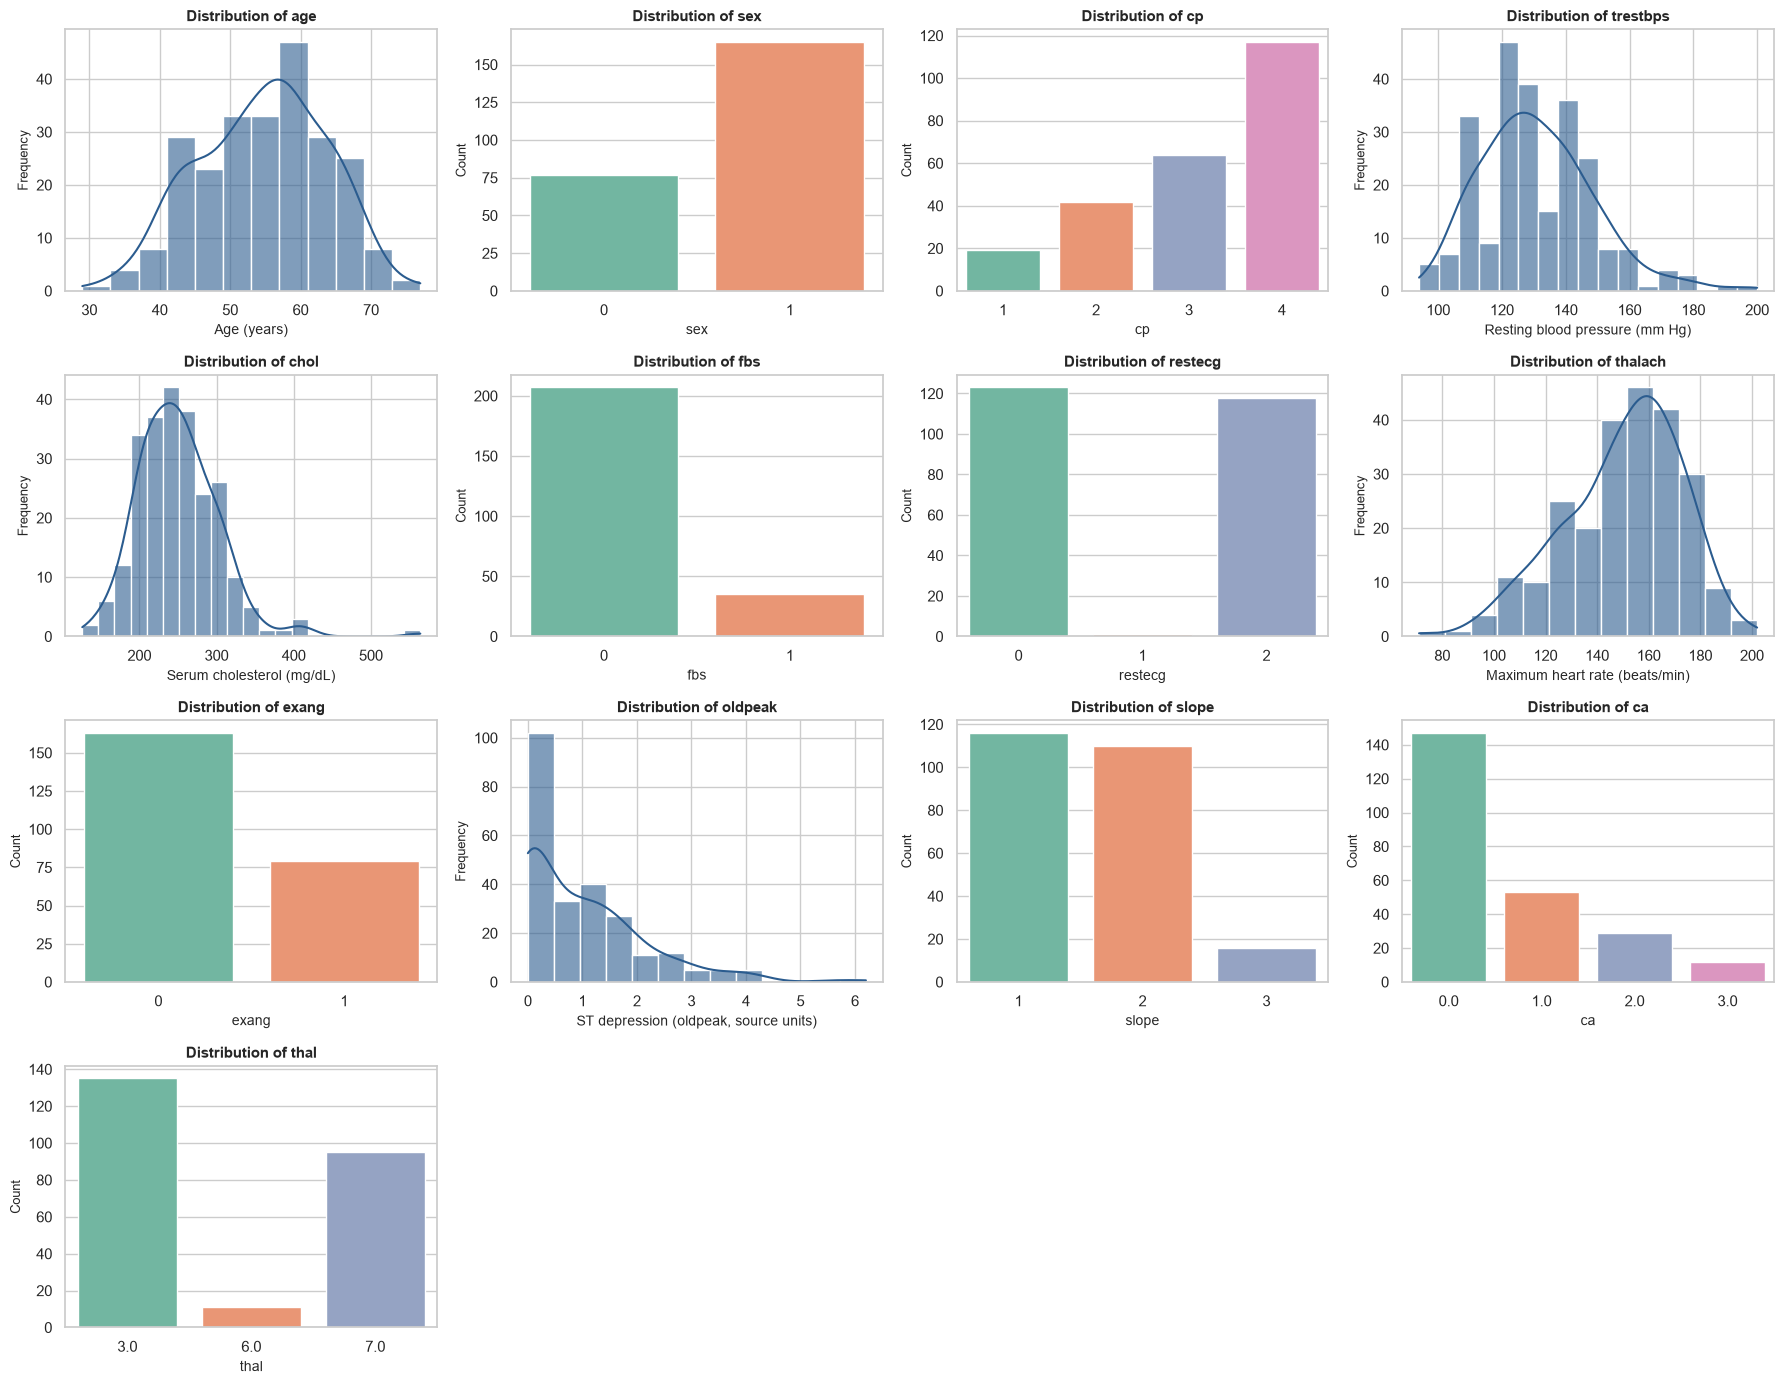

In [54]:
# Set style
sns.set_theme(style="whitegrid")
all_cols = X_train.columns.tolist()
# Define grid: 4 columns wide, rows calculated automatically
n_cols = 4
n_rows = math.ceil(len(all_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = axes.flatten()  # Flatten 2D array into 1D for easy iteration
for i, col in enumerate(all_cols):
    ax = axes[i]
    # If column is continuous numeric (e.g., > 10 unique values)
    if col in numeric_cols and raw[col].nunique() > 5:
        sns.histplot(
            data=X_train,
            x=col,
            kde=True,
            ax=ax,
            color="#2b5c8f",
            edgecolor="white",
            alpha=0.6,
        )
        ax.set_ylabel("Frequency", fontsize=9)
    else:
        # Categorical / discrete column: count plot
        sns.countplot(
            data=X_train,
            x=col,
            hue=col,
            legend=False,
            ax=ax,
            palette="Set2",
            order=sorted(raw[col].dropna().unique()),
        )
        ax.set_ylabel("Count", fontsize=9)
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(FEATURE_LABELS.get(col, col), fontsize=10)
# Remove unused empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Univariate EDA Notes

#### Obsetvation:
- `age` and `thalach` show relatively balanced distributions with no major skewness.
- `trestbps` is mildly right-skewed, with a few high-value observations.
- `chol` is right-skewed and contains several extreme high values.
- `oldpeak` is strongly right-skewed and may be a candidate for transformation later.
- `sex`, `fbs`, and `exang` show unequal category frequencies, but no immediate action is required.
- `restecg = 1`, `slope = 3`, and `thal = 6` are relatively rare categories.
- `cp` and `ca` also have uneven category distributions.

#### Next Action:
At this stage, no transformation or removal is applied. These observations are only noted for further investigation.

Potential preprocessing decisions such as:
- log transformation for skewed numerical features,
- outlier treatment,
- rare-category handling,
- scaling or encoding,

will be considered after completing bivariate and multivariate EDA and evaluating their relationships with the target.

## 3.1. Bivariate Analysis


## Relationship between numeric feature and target comparisons



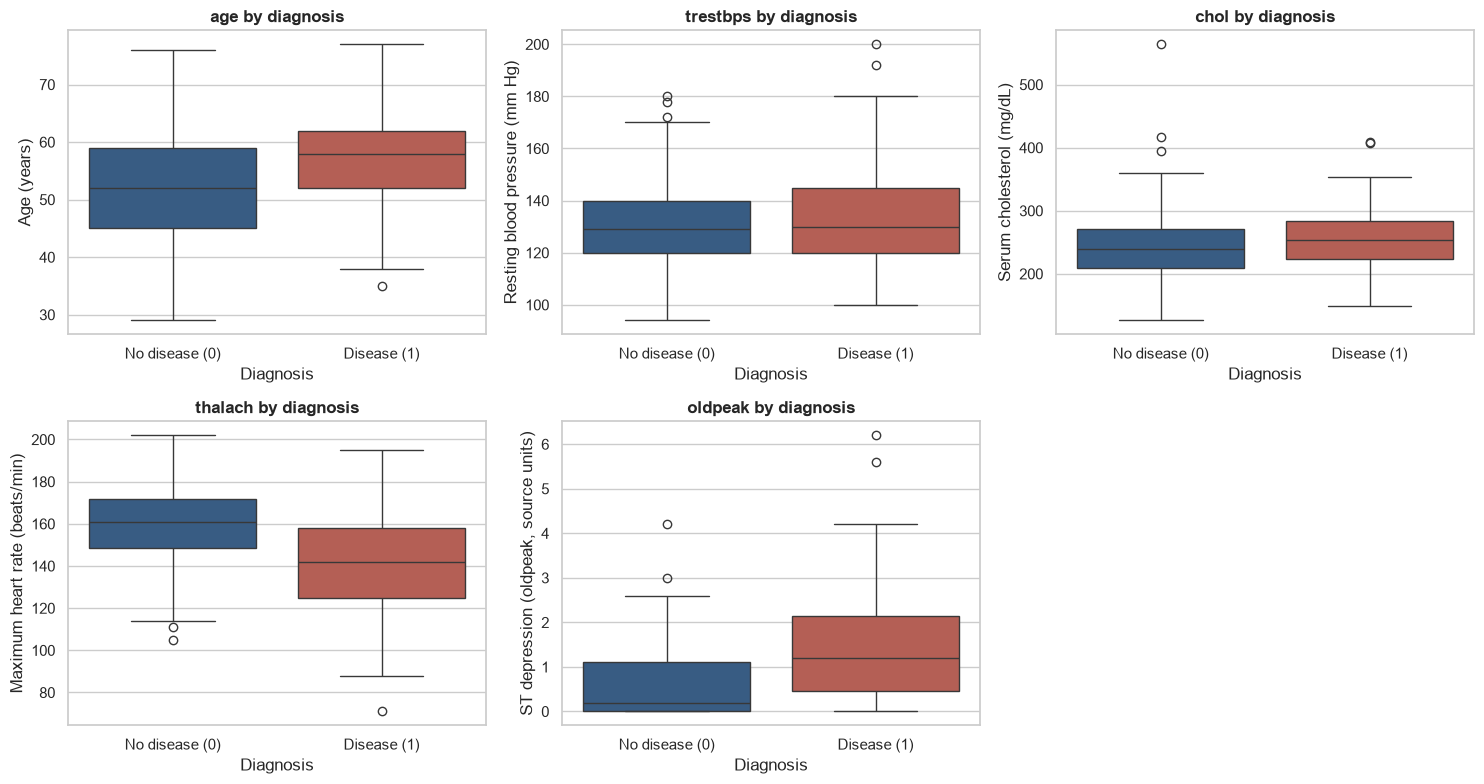

In [55]:
train_eda = X_train.copy()
train_eda["target"] = y_train.values
train_eda["diagnosis"] = train_eda["target"].map(TARGET_LABELS)

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=train_eda,
        x='diagnosis',
        y=col,
        hue='diagnosis',
        order=list(TARGET_COLORS.keys()),
        palette=TARGET_COLORS,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} by diagnosis', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Diagnosis')
    axes[i].set_ylabel(FEATURE_LABELS.get(col, col))

# Hide unused subplots
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()



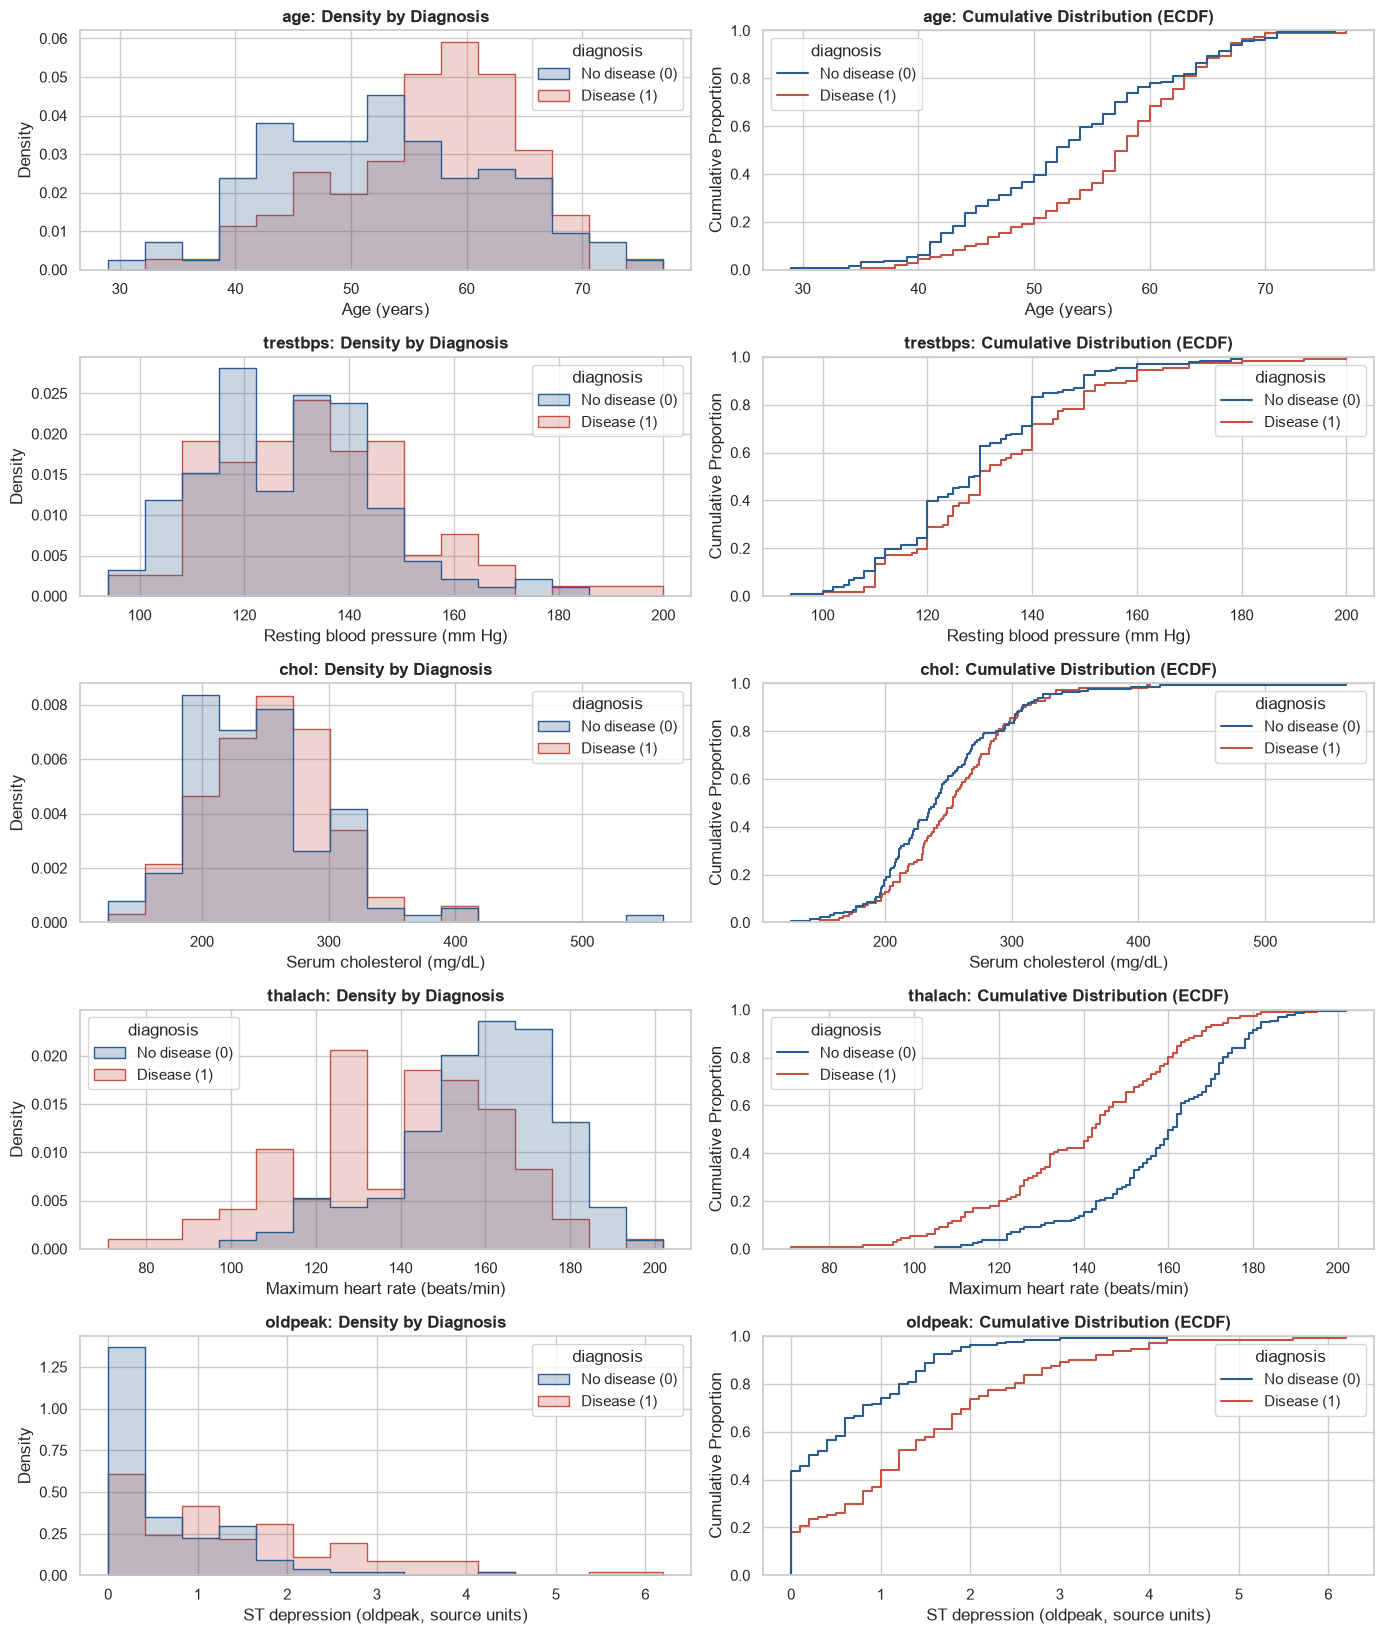

In [56]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 3.3 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Density histogram with step lines
    sns.histplot(
        data=train_eda,
        x=col,
        hue='diagnosis',
        hue_order=list(TARGET_COLORS.keys()),
        palette=TARGET_COLORS,
        stat='density',
        common_norm=False,
        element='step',
        bins=15,
        alpha=0.25,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{col}: Density by Diagnosis', fontweight='bold')
    axes[i, 0].set_xlabel(FEATURE_LABELS.get(col, col))
    axes[i, 0].set_ylabel('Density')

    # Empirical cumulative distribution (ECDF)
    sns.ecdfplot(
        data=train_eda,
        x=col,
        hue='diagnosis',
        hue_order=list(TARGET_COLORS.keys()),
        palette=TARGET_COLORS,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{col}: Cumulative Distribution (ECDF)', fontweight='bold')
    axes[i, 1].set_xlabel(FEATURE_LABELS.get(col, col))
    axes[i, 1].set_ylabel('Cumulative Proportion')

plt.tight_layout()
plt.show()


### Numerical Features vs Target

- `thalach` shows clear class separation: patients with heart disease tend to have lower maximum heart rates.
- `oldpeak` also shows strong separation: patients with heart disease generally have higher ST depression values.
- `age` shows moderate separation, with the disease group tending to be older.
- `trestbps` shows substantial overlap between the two classes, suggesting relatively weak univariate signal.
- `chol` also shows considerable overlap and appears to provide limited univariate discrimination.

Overall, `thalach` and `oldpeak` appear to contain the strongest univariate signal among the numerical features examined. However, no feature alone cleanly separates the two classes, so interactions with other features should be investigated before making feature-selection decisions.

## Relationship between categorical columns and target

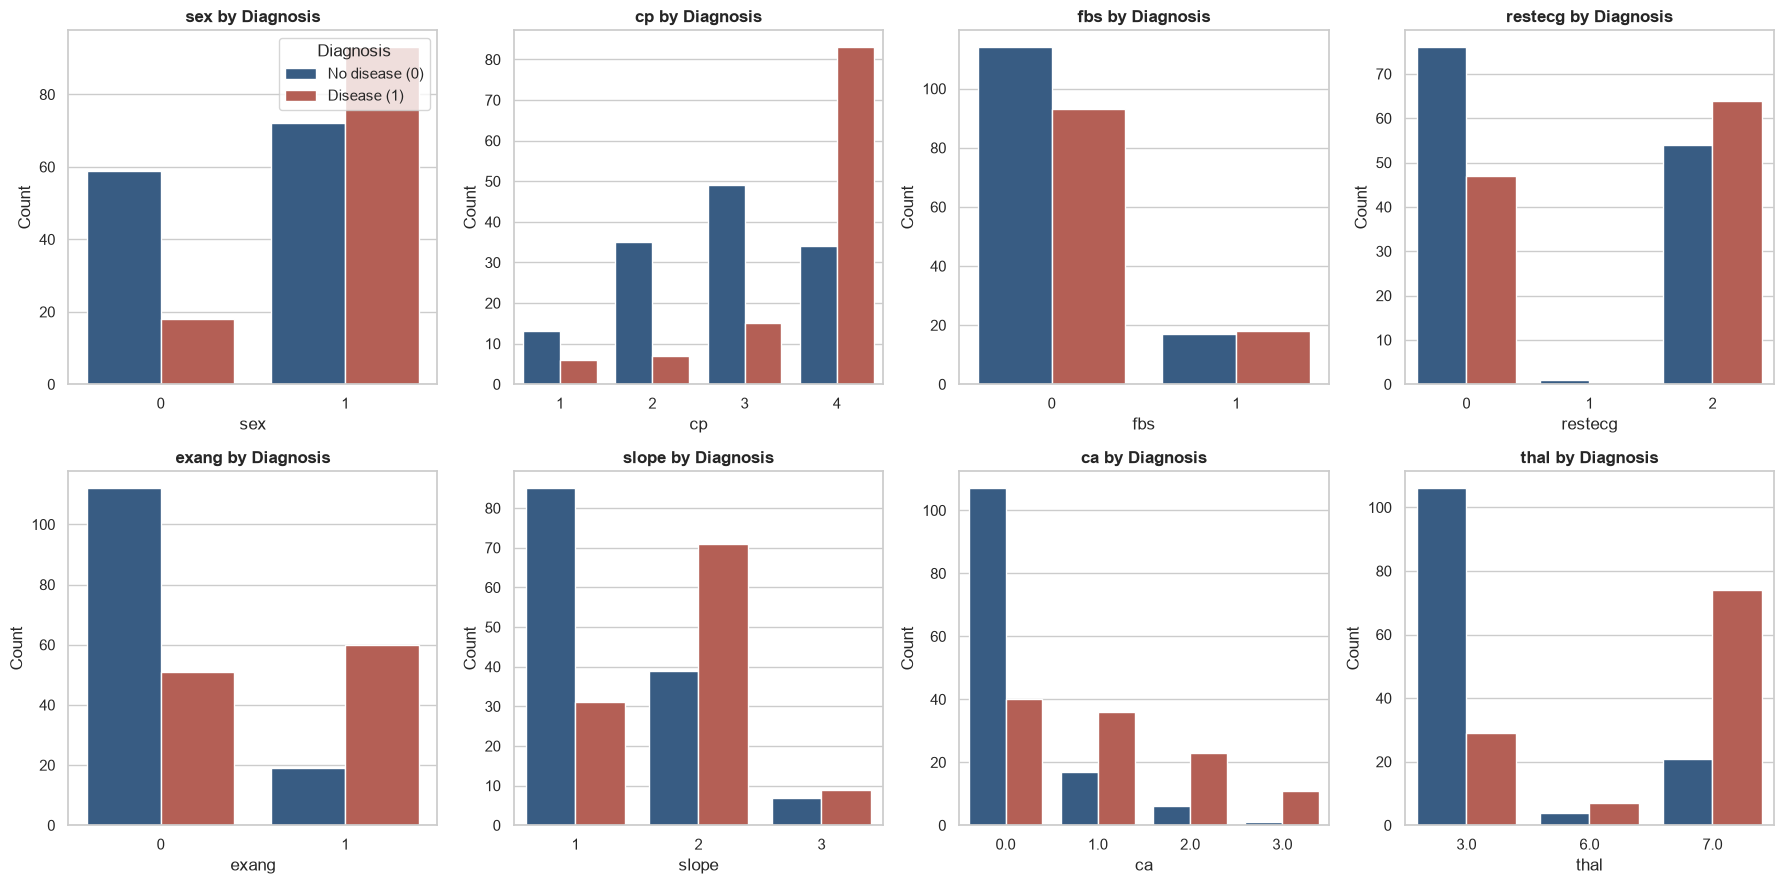

In [57]:
train_eda = X_train.copy()
train_eda["target"] = y_train.values
train_eda["diagnosis"] = train_eda["target"].map(TARGET_LABELS)

n_cols = 4  # 4 columns x 2 rows fits the 8 categorical features cleanly
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=train_eda,
        x=col,
        hue='diagnosis',
        hue_order=list(TARGET_COLORS.keys()),
        palette=TARGET_COLORS,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} by Diagnosis', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(FEATURE_LABELS.get(col, col))
    axes[i].set_ylabel('Count')

    # Keep a single clean legend on the first plot
    if i == 0:
        axes[i].legend(title='Diagnosis', loc='upper right')
    else:
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()

# Remove any unused subplot axes
for ax in axes[len(categorical_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


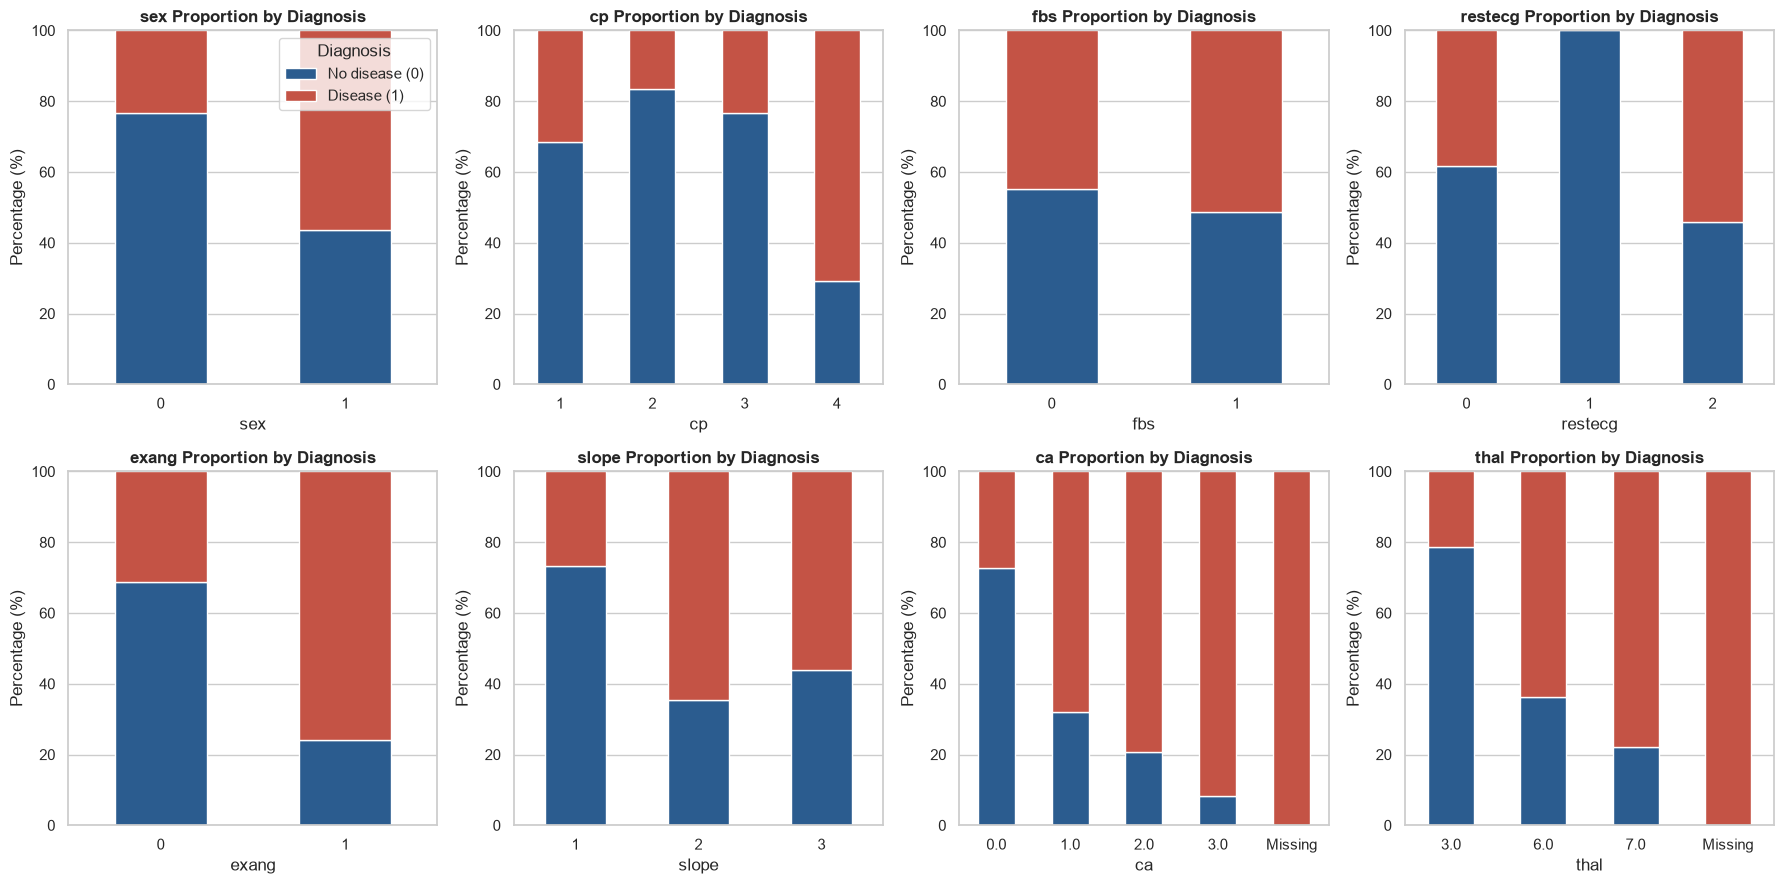

In [58]:
train_eda = X_train.copy()
train_eda["target"] = y_train.values
train_eda["diagnosis"] = train_eda["target"].map(TARGET_LABELS)

n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    # Cross-tabulate and normalize per row (category level)
    crosstab_norm = (
        pd.crosstab(train_eda[col].fillna("Missing"), train_eda["diagnosis"], normalize="index")
        .reindex(columns=list(TARGET_COLORS.keys()))
    ) * 100

    crosstab_norm.plot(
        kind='bar',
        stacked=True,
        color=[TARGET_COLORS[k] for k in crosstab_norm.columns],
        ax=axes[i],
        edgecolor='white',
        rot=0
    )
    axes[i].set_title(f'{col} Proportion by Diagnosis', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(FEATURE_LABELS.get(col, col))
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 100)

    if i == 0:
        axes[i].legend(title='Diagnosis', loc='upper right')
    else:
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()

for ax in axes[len(categorical_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Categorical Features vs Target

- `cp`, `thal`, `ca`, and `exang` show the clearest differences in disease proportion across categories, suggesting strong univariate predictive signal.
- `ca` shows an approximately monotonic pattern: higher values are associated with a higher proportion of heart disease.
- `slope` and `sex` also show noticeable class differences, although the separation is weaker.
- `restecg` shows some variation across categories, but the rare `restecg=1` level contains too few observations for a reliable conclusion.
- `fbs` shows relatively similar disease proportions across its two levels, suggesting weak univariate signal.
- Rare categories and missing-value groups should be interpreted cautiously because their observed target proportions may be unstable due to small sample sizes.

No feature-selection or encoding decisions are made at this stage. These patterns will be considered together with multivariate analysis and model-based validation.

## Relationships among numeric predictors

Use the correlation matrix to spot linear relationships among continuous measurements. Correlations summarize association and may miss nonlinear patterns; encoded category values should not be included in this numeric correlation plot.

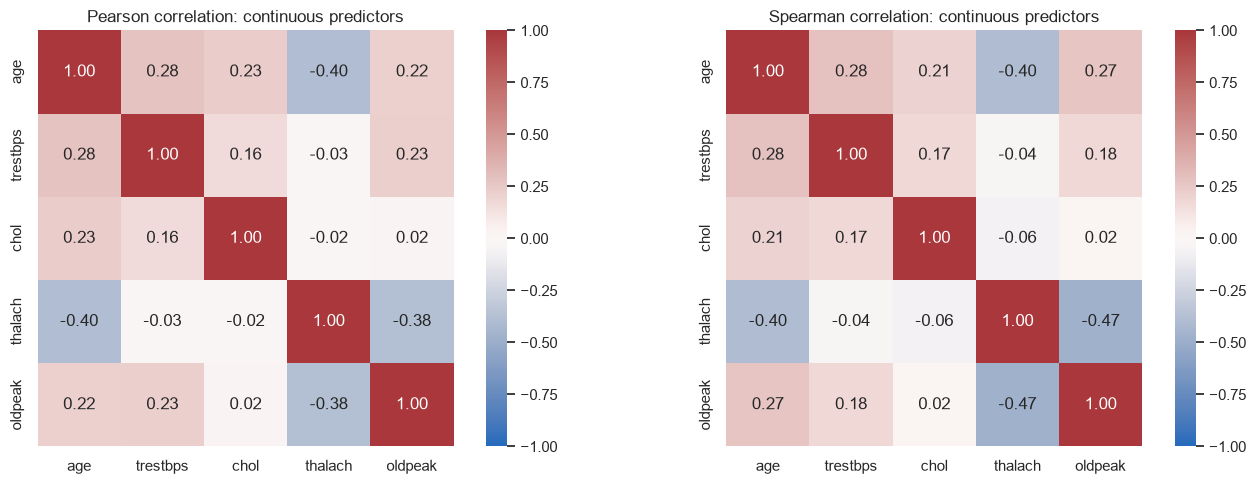

pearson_r
age      thalach      -0.395
thalach  oldpeak      -0.381
age      trestbps      0.277
         chol          0.227
trestbps oldpeak       0.226
age      oldpeak       0.215
trestbps chol          0.159
         thalach      -0.030
chol     oldpeak       0.024
         thalach      -0.021

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method in zip(axes, ['pearson', 'spearman']):
    numeric_corr = X_train[numeric_cols].corr(method=method)
    sns.heatmap(numeric_corr, annot=True, cmap='vlag', center=0,
                vmin=-1, vmax=1, fmt='.2f', square=True, ax=ax)
    ax.set_title(f'{method.title()} correlation: continuous predictors')
plt.tight_layout()
plt.show()

pearson_corr = X_train[numeric_cols].corr(method='pearson')
corr_pairs = (pearson_corr.where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool))
              .stack().dropna().rename('pearson_r').sort_values(key=abs, ascending=False))
display(corr_pairs.to_frame().round(3))


### Correlation Between Continuous Features

- No strong correlation is observed among the continuous predictors, suggesting no major multicollinearity issue.
- `age` and `thalach` show a moderate negative correlation (`r ≈ -0.40`), indicating that maximum heart rate tends to decrease with age.
- `thalach` and `oldpeak` also show a moderate negative relationship. The stronger Spearman correlation (`ρ ≈ -0.47`) compared with Pearson (`r ≈ -0.38`) suggests the relationship may be monotonic but not perfectly linear.
- Other feature pairs show only weak correlations.
- `chol` appears largely independent from the other continuous predictors.

No feature is removed based on correlation at this stage.

## Multivariate EDA


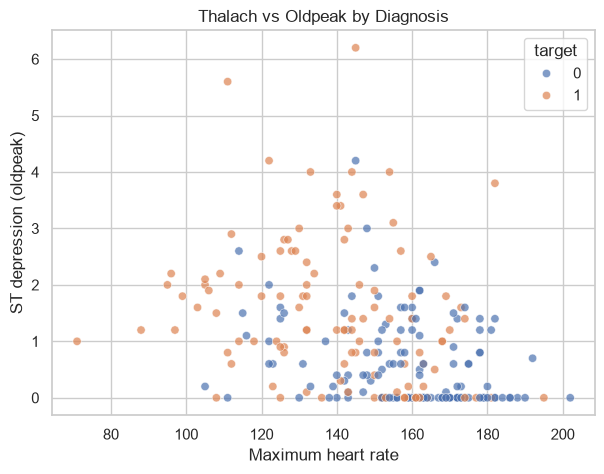

In [60]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=train_eda,
    x="thalach",
    y="oldpeak",
    hue="target",
    alpha=0.7
)

plt.title("Thalach vs Oldpeak by Diagnosis")
plt.xlabel("Maximum heart rate")
plt.ylabel("ST depression (oldpeak)")
plt.show()

### Thalach × Oldpeak Interaction

The combination of `thalach` and `oldpeak` does not show clear class separation, with substantial overlap between the two diagnosis groups.

There is, however, a weak tendency for disease cases to appear more frequently at lower `thalach` and higher `oldpeak` values, while no-disease cases are more concentrated around higher `thalach` and low `oldpeak`.

The interaction is therefore potentially informative, but not strong enough to draw a clear decision boundary from EDA alone.

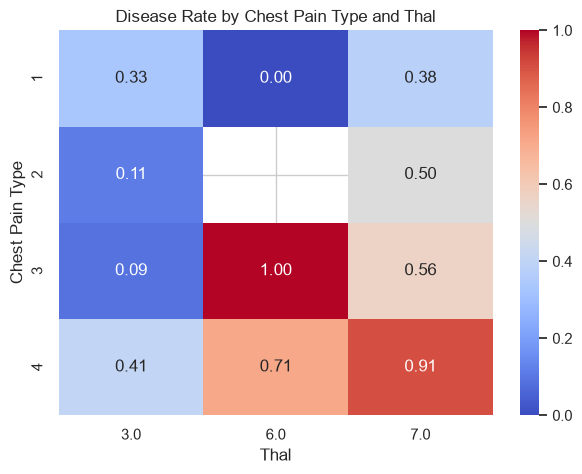

In [61]:
cp_thal_rate = pd.crosstab(
    train_eda["cp"],
    train_eda["thal"],
    values=train_eda["target"],
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(cp_thal_rate, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Disease Rate by Chest Pain Type and Thal")
plt.xlabel("Thal")
plt.ylabel("Chest Pain Type")
plt.show()

<Axes: xlabel='thal', ylabel='cp'>

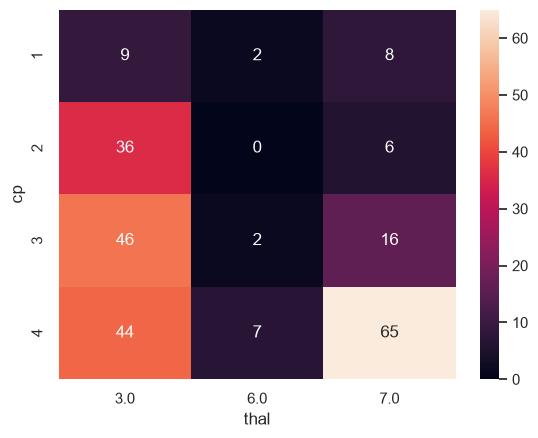

In [62]:
counts = pd.crosstab(
    train_eda["cp"],
    train_eda["thal"]
)

sns.heatmap(counts, annot=True, fmt="d")

### Interaction: Chest Pain Type × Thal

The joint distribution of `cp` and `thal` shows noticeable differences in disease rate across feature combinations.

In particular, combinations involving `cp=4` and `thal=7` show a substantially higher disease rate, while several combinations involving `thal=3` show lower disease rates.

This suggests that the combination of chest pain type and thallium test result may contain useful predictive information beyond their individual effects.


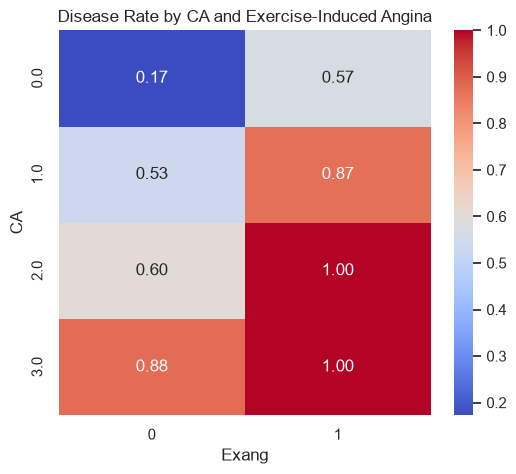

In [63]:
ca_exang_rate = pd.crosstab(
    train_eda["ca"],
    train_eda["exang"],
    values=train_eda["target"],
    aggfunc="mean"
)

plt.figure(figsize=(6, 5))
sns.heatmap(ca_exang_rate, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Disease Rate by CA and Exercise-Induced Angina")
plt.xlabel("Exang")
plt.ylabel("CA")
plt.show()

<Axes: xlabel='exang', ylabel='ca'>

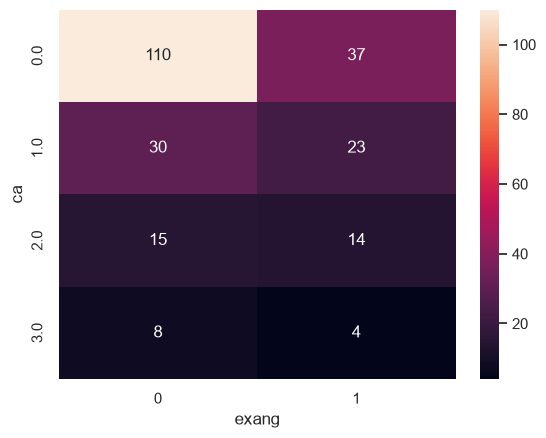

In [64]:
counts = pd.crosstab(
    train_eda["ca"],
    train_eda["exang"]
)

sns.heatmap(counts, annot=True, fmt="d")


### Interaction: CA × Exercise-Induced Angina

- Disease rate increases substantially as `ca` increases, regardless of `exang`.
- Within most `ca` levels, patients with `exang=1` also show a noticeably higher disease rate than those with `exang=0`.
- This suggests that `ca` and `exang` may provide complementary predictive information.
- The interaction is particularly visible for `ca=0–2`, where sample sizes are still reasonably informative.
- Results for `ca=3` should be interpreted cautiously because of the small number of observations.

Overall, `ca` appears to be a strong predictor on its own, while `exang` may provide additional signal within each `ca` level.

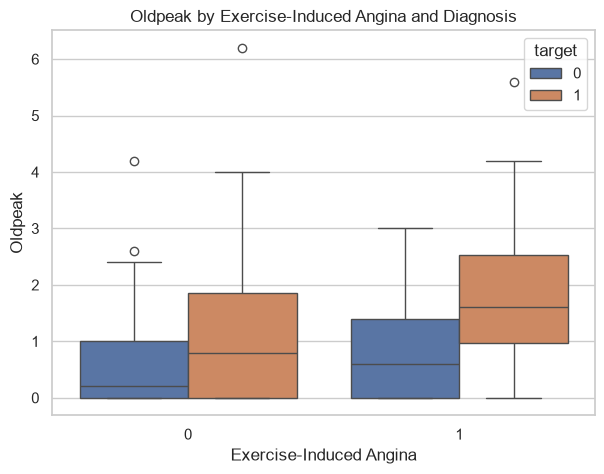

In [65]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=train_eda,
    x="exang",
    y="oldpeak",
    hue="target"
)

plt.title("Oldpeak by Exercise-Induced Angina and Diagnosis")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Oldpeak")
plt.show()

### Interaction: Oldpeak × Exercise-Induced Angina

- Within both `exang=0` and `exang=1`, patients with heart disease tend to have higher `oldpeak` values.
- `oldpeak` therefore retains predictive signal even after conditioning on exercise-induced angina.
- `exang=1` is also associated with generally higher `oldpeak` values.
- The plot suggests complementary information from `oldpeak` and `exang`, but there is no clear evidence of a strong interaction effect.

No feature engineering decision is made at this stage.

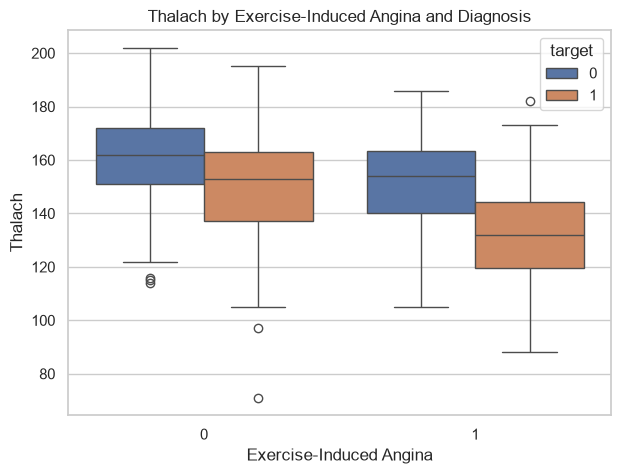

In [66]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=train_eda,
    x="exang",
    y="thalach",
    hue="target"
)

plt.title("Thalach by Exercise-Induced Angina and Diagnosis")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Thalach")
plt.show()

### Interaction: Thalach × Exercise-Induced Angina

- Patients with heart disease tend to have lower `thalach` values within both `exang` groups.
- Among patients with `exang=1`, the difference in `thalach` between the disease and no-disease groups appears larger.
- Disease cases with `exang=1` show particularly low maximum heart rates compared with the other groups.
- This pattern suggests a potential interaction between `thalach` and `exang`, although substantial overlap remains and the interaction should be validated during modeling.

No interaction feature is created at this stage.

## EDA Summary

### 1. Data Quality
- No major data-quality issue was identified after the initial inspection.
- Several numerical observations were flagged by the IQR rule, mainly in `trestbps`, `chol`, `thalach`, and `oldpeak`.
- These values appear plausible rather than invalid, so they are retained.
- Some categorical levels are rare, especially in `restecg`, `slope`, and `thal`.
- Rare levels are kept for now because low frequency alone is not sufficient justification for removal or merging.

### 2. Univariate Analysis
- `age` and `thalach` show relatively regular distributions.
- `trestbps` is mildly right-skewed.
- `chol` is right-skewed and contains several high-value observations.
- `oldpeak` is strongly right-skewed.
- Several categorical variables have uneven category frequencies, but no category is removed at this stage.

No transformation is applied solely based on univariate distribution shape.

### 3. Numerical Features vs Target
- `thalach` shows one of the clearest class differences: patients with heart disease tend to have lower maximum heart rates.
- `oldpeak` also shows strong univariate signal, with disease cases generally having higher ST-depression values.
- `age` shows moderate separation, with the disease group tending to be older.
- `trestbps` and `chol` show substantial overlap between classes and appear to provide weaker univariate discrimination.

### 4. Categorical Features vs Target
- `ca`, `thal`, `cp`, and `exang` show the clearest differences in disease proportions across categories.
- `ca` shows an approximately monotonic pattern: higher values are associated with a higher proportion of heart disease.
- `slope` and `sex` also show noticeable differences between diagnosis groups.
- `restecg` shows weaker and less stable patterns because some levels contain very few observations.
- `fbs` shows relatively similar disease proportions across its levels, suggesting weak univariate signal.

### 5. Feature-to-Feature Relationships
- No strong correlation is observed among the continuous predictors, suggesting no major multicollinearity issue.
- `age` and `thalach` show a moderate negative relationship.
- `thalach` and `oldpeak` also show a moderate negative relationship.
- The remaining continuous feature pairs show only weak correlations.

No continuous feature is removed based on correlation.

### 6. Multivariate Analysis
- `thalach × oldpeak` does not produce clear class separation, although disease cases tend to appear more frequently at lower `thalach` and higher `oldpeak`.
- `cp × thal` shows meaningful differences in disease rate across category combinations, suggesting potentially useful combined information.
- `ca × exang` shows a strong and consistent pattern:
  - disease rate increases as `ca` increases;
  - within most `ca` levels, `exang=1` is associated with a higher disease rate.
- `oldpeak × exang` suggests that both variables provide complementary predictive information, although no strong interaction effect is visually evident.
- `thalach × exang` shows a potentially useful interaction:
  - disease cases tend to have lower `thalach` within both `exang` groups;
  - the difference appears stronger when `exang=1`.

### 7. Main EDA Findings

Features showing the strongest apparent signal:

**Strong signal**
- `ca`
- `thal`
- `cp`
- `exang`
- `thalach`
- `oldpeak`

**Moderate signal**
- `age`
- `slope`
- `sex`

**Weaker univariate signal**
- `trestbps`
- `chol`
- `fbs`
- `restecg`

These groups are based only on exploratory analysis and should not be treated as final feature-importance rankings.

### 8. Candidate Interactions for Later Evaluation
Potential interactions worth testing during feature engineering:
- `ca × exang`
- `thalach × exang`
- `cp × thal`

These are only candidates from EDA and should be validated using cross-validation before being retained.

## Prepare the modeling split

Create a stratified holdout for the baseline pipeline. Fit imputation and encoding on training data only. The whole-sample EDA above is descriptive; any model decisions informed by it require independent validation. This notebook prepares features and does not train a predictive model.

In [68]:
from pathlib import Path
import pandas as pd

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "cleveland_cleaned.csv"
raw.to_csv(output_path, index=False)

print(f"Đã lưu tại: {output_path}")


Đã lưu tại: ../data/processed/cleveland_cleaned.csv
